In [1]:
!pip install xlsxwriter
import io, requests, zipfile, pandas as pd, numpy as np
from datetime import datetime, timedelta
import os
HNX30_TICKERS = [
    "BVS","CAP","CEO","DHT","DTD","DVM","DXP","HUT","IDC","IDV",
    "L14","L18","LAS","LHC","MBS","NTP","PLC","PSD","PVB","PVC",
    "PVI","PVS","SHS","SLS","TMB","TNG","TVD","VC3","VCS","VGP"
]
START_DATE = datetime(2020, 1, 1)
END_DATE = datetime(2024, 12, 31)
LOOKBACK_DAYS_TO_FIND_LATEST = 15
FOLDER_DATA = "data_hnx30_cafef"
os.makedirs(FOLDER_DATA, exist_ok=True)
def normalize_headers(df):
    df.columns = [str(c).strip().replace("<", "").replace(">", "") for c in df.columns]
    return df
def detect_and_parse_date(df):
    for col in df.columns:
        low = str(col).lower()
        if low in ("date", "tradedate", "dt", "ngay", "dtyyyymmdd"):
            try:
                if pd.api.types.is_numeric_dtype(df[col]):
                    df["Date"] = pd.to_datetime(df[col].astype(int).astype(str), format="%Y%m%d", errors="coerce")
                else:
                    df["Date"] = pd.to_datetime(df[col], dayfirst=True, errors="coerce")
                return df.dropna(subset=["Date"])
            except Exception:
                continue
    return df
def normalize_columns_to_standard(df):
    rename_map = {
        "mack": "Ticker", "symbol": "Ticker", "ma": "Ticker",
        "giadongcua": "Close", "closeprice": "Close",
        "giamocua": "Open", "openprice": "Open",
        "giacaonhat": "High", "highprice": "High",
        "giathapnhat": "Low", "lowprice": "Low",
        "khoiluong": "Volume", "kl": "Volume", "totalvolume": "Volume",
        "dt": "Date", "date": "Date", "tradedate": "Date", "dtyyyymmdd": "Date"
    }
    current_map = {}
    for c in df.columns:
        cl = str(c).lower().replace("_", "").replace(" ", "")
        if cl in rename_map:
            current_map[c] = rename_map[cl]
    return df.rename(columns=current_map)

def clean_numeric_columns(df):
    numeric_cols = ["Open", "High", "Low", "Close", "Volume"]
    for col in numeric_cols:
        if col in df.columns:
            s = df[col].astype(str)
            s = s.str.replace(r"[^0-9.,-]", "", regex=True)
            is_vn = s.str.contains(r'\.\d{3},', regex=True).any()
            if is_vn:
                s = s.str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
            else:
                s = s.str.replace(',', '', regex=False)
            df[col] = pd.to_numeric(s, errors='coerce')
    return df

def process_zip_response(content, tickers_filter=None):
    try:
        z = zipfile.ZipFile(io.BytesIO(content))
        parts = []
        for name in z.namelist():
            if name.lower().endswith((".csv", ".txt")):
                with z.open(name) as f:
                    try:
                        df = pd.read_csv(f, sep=",")
                    except Exception:
                        f.seek(0)
                        df = pd.read_csv(f, encoding="latin1", sep=None, engine="python")
                df = normalize_headers(df)
                df = normalize_columns_to_standard(df)
                df = detect_and_parse_date(df)
                df = clean_numeric_columns(df)
                if "Ticker" in df.columns and "Date" in df.columns:
                    df["Ticker"] = df["Ticker"].astype(str).str.upper().str.strip()
                    if tickers_filter:
                        df = df[df["Ticker"].isin(tickers_filter)]
                    if not df.empty:
                        parts.append(df)
        if not parts:
            return pd.DataFrame()
        return pd.concat(parts, ignore_index=True)
    except Exception:
        return pd.DataFrame()

def load_latest_cafef(tickers_filter=None, n_days=LOOKBACK_DAYS_TO_FIND_LATEST):
    today = datetime.now()
    for i in range(n_days):
        publish_day = today - timedelta(days=i)
        for j in range(3):
            data_day = publish_day - timedelta(days=j)
            if data_day.weekday() >= 5:  # Skip weekend
                continue
            url = f"https://cafef1.mediacdn.vn/data/ami_data/{publish_day.strftime('%Y%m%d')}/CafeF.SolieuGD.Upto{data_day.strftime('%d%m%Y')}.zip"
            try:
                r = requests.get(url, timeout=10)
                if r.status_code == 200:
                    df = process_zip_response(r.content, tickers_filter)
                    if not df.empty:
                        print(f"✅ Dữ liệu mới nhất từ: {data_day.strftime('%d/%m/%Y')}")
                        return df
            except requests.exceptions.RequestException:
                continue
    print("❌ Không tìm thấy dữ liệu mới nhất.")
    return pd.DataFrame()

def clean_and_align(df_all, tickers, start_date, end_date):
    clean_data = {}
    full_index = pd.date_range(start=start_date, end=end_date, freq='B')
    for t in tickers:
        df_t = df_all[df_all["Ticker"] == t].copy()
        if df_t.empty:
            print(f"⚠️ Không có dữ liệu cho {t}")
            continue
        df_t = df_t[(df_t["Date"] >= start_date) & (df_t["Date"] <= end_date)]
        df_t = df_t.sort_values("Date").set_index("Date")
        df_t.loc[:, ["Open", "High", "Low", "Close", "Volume"]] = df_t[["Open","High","Low","Close","Volume"]].clip(lower=0)
        df_t = df_t.reindex(full_index)
        df_t["Ticker"] = t
        df_t[["Open","High","Low","Close"]] = df_t[["Open","High","Low","Close"]].interpolate(method="linear")
        df_t["Volume"] = df_t["Volume"].fillna(0)
        df_t = df_t[df_t["Volume"] > 0]  # loại bỏ ngày không giao dịch
        clean_data[t] = df_t.reset_index().rename(columns={"index":"Date"})
    return clean_data
# ---------------- MAIN ----------------
if __name__ == "__main__":

    print("⏳ Đang tải dữ liệu HNX30 từ CafeF...")
    df_all = load_latest_cafef(tickers_filter=HNX30_TICKERS)

    if df_all.empty:
        print("❌ Không tải được dữ liệu HNX30 từ CafeF.")
    else:
        print(f"✅ Đã tải {len(df_all)} dòng dữ liệu thô từ CafeF.")

        # Lọc đúng giai đoạn yêu cầu
        df_all = df_all[
            (df_all["Date"] >= pd.Timestamp("2020-01-01")) &
            (df_all["Date"] <= pd.Timestamp("2024-12-31"))
        ]

        print(f"📌 Dữ liệu sau khi lọc giai đoạn 2020–2024: {len(df_all)} dòng.")

        # Làm sạch & căn chỉnh từng mã
        hnx30_data = clean_and_align(
            df_all,
            HNX30_TICKERS,
            pd.Timestamp("2020-01-01"),
            pd.Timestamp("2024-12-31")
        )

        # Xuất ra Excel
        output_file = f"{FOLDER_DATA}/HNX30_Data_2020_2024.xlsx"
        with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
            for ticker, df_t in hnx30_data.items():
                df_t.to_excel(writer, sheet_name=ticker[:31], index=False)

        print(f"💾 ĐÃ LƯU FILE: {output_file}")
        print("🎉 Hoàn thành lấy dữ liệu HNX30 2020–2024!")


⏳ Đang tải dữ liệu HNX30 từ CafeF...
✅ Dữ liệu mới nhất từ: 21/11/2025
✅ Đã tải 103466 dòng dữ liệu thô từ CafeF.
📌 Dữ liệu sau khi lọc giai đoạn 2020–2024: 35478 dòng.
💾 ĐÃ LƯU FILE: data_hnx30_cafef/HNX30_Data_2020_2024.xlsx
🎉 Hoàn thành lấy dữ liệu HNX30 2020–2024!


In [2]:
import pandas as pd
#HÀM XỬ LÝ KL VÀ GIÁ
def clean_volume(x):
    if isinstance(x, str):
        x = x.upper().replace(',', '')
        if 'K' in x:
            return float(x.replace('K', '')) * 1_000
        elif 'M' in x:
            return float(x.replace('M', '')) * 1_000_000
        elif 'B' in x:
            return float(x.replace('B', '')) * 1_000_000_000
        return float(x)
    return x
def clean_price(x):
    if isinstance(x, str):
        return float(x.replace(',', ''))
    return x
# HÀM ĐỌC & XỬ LÝ CSV
def get_data_csv():
    file_path = 'Dữ liệu Lịch sử HNX.csv'
    try:
        df = pd.read_csv(file_path)
        print("📄 Đã đọc dữ liệu thô từ CSV.")

        # Đổi tên cột
        mapping = {
            'Ngày': 'Date',
            'Lần cuối': 'Close',
            'Mở': 'Open',
            'Cao': 'High',
            'Thấp': 'Low',
            'KL': 'Volume'
        }
        df = df.rename(columns=mapping)

        # Xử lý ngày
        df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
        df['year'] = df['Date'].dt.year

        # Làm sạch giá
        for col in ['Close', 'Open', 'High', 'Low']:
            df[col] = df[col].apply(clean_price)

        # Làm sạch khối lượng
        df['Volume'] = df['Volume'].apply(clean_volume)

        # Sắp xếp thời gian
        df = df.sort_values('Date')
        df['Date'] = df['Date'].dt.strftime('%d/%m/%Y')

        print(f"✅ Xử lý CSV thành công: {len(df)} dòng.")
        return df

    except FileNotFoundError:
        print("❌ Không tìm thấy file CSV.")
        return None
# CHẠY CHƯƠNG TRÌNH
data = get_data_csv()
if data is None:
    print("❌ Không thể xử lý dữ liệu thô.")
else:
    # Xuất Excel theo từng năm
    with pd.ExcelWriter("hnxindex_data_2020_2024.xlsx", engine="openpyxl") as writer:
        for year in sorted(data["year"].unique()):
            df_year = data[data["year"] == year].copy()
            # Đặt thứ tự cột
            cols = ['Date'] + [c for c in df_year.columns if c not in ['Date','year']]
            df_year = df_year[cols]
            df_year.to_excel(writer, sheet_name=str(year), index=False)
            # 🔧 FIX: dùng len(df_year), không dùng len[df_year]
            print(f"📄 Xuất sheet năm {year}: {len(df_year)} dòng.")
    print("\n🎉 DONE! File output: hnxindex_data_2020_2024.xlsx")

📄 Đã đọc dữ liệu thô từ CSV.
✅ Xử lý CSV thành công: 1250 dòng.
📄 Xuất sheet năm 2020: 252 dòng.
📄 Xuất sheet năm 2021: 250 dòng.
📄 Xuất sheet năm 2022: 249 dòng.
📄 Xuất sheet năm 2023: 249 dòng.
📄 Xuất sheet năm 2024: 250 dòng.

🎉 DONE! File output: hnxindex_data_2020_2024.xlsx


In [3]:
for ticker, df in hnx30_data.items():
    print(f"===== {ticker} =====")
    print(df.isna().sum())
    print("\n")

===== BVS =====
Date      0
Ticker    0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


===== CAP =====
Date      0
Ticker    0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


===== CEO =====
Date      0
Ticker    0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


===== DHT =====
Date      0
Ticker    0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


===== DTD =====
Date      0
Ticker    0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


===== DVM =====
Date      0
Ticker    0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


===== DXP =====
Date      0
Ticker    0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


===== HUT =====
Date      0
Ticker    0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


===== IDC =====
Date      0
Ticker    0
Open      0
High      0
Low       0
Clos

In [4]:
import pandas as pd
print("TIỀN XỬ LÝ DỮ LIỆU HNX30")
for t in list(hnx30_data.keys()):
    df = hnx30_data[t].copy()
     # 1. Chuẩn hoá kiểu dữ liệu
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    # 2. Loại bỏ dòng có Date lỗi
    df = df.dropna(subset=['Date'])
    # 3. Sắp xếp theo ngày
    df = df.sort_values('Date')
    # 4. Loại duplicate theo Date
    df = df.drop_duplicates(subset=['Date'])
    # 5. Loại dòng không có giá đóng cửa (ngày không giao dịch)
    df = df.dropna(subset=['Close'])
    # 6. Đảm bảo các cột numeric đúng dạng
    num_cols = ["Open", "High", "Low", "Close", "Volume"]
    for col in num_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    # 7. Loại dòng volume âm hoặc NaN
    df = df[df["Volume"].fillna(0) >= 0]
    # 8. Reset index
    hnx30_data[t] = df.reset_index(drop=True)
print("HOÀN TẤT TIỀN XỬ LÝ HNX30\n")

TIỀN XỬ LÝ DỮ LIỆU HNX30
HOÀN TẤT TIỀN XỬ LÝ HNX30



In [5]:
print("=== PHÂN BỐ PHIÊN THEO NĂM ===")
for t, df in hnx30_data.items():
    df["Year"] = df["Date"].dt.year
    print(f"\n{t}:")
    print(df.groupby("Year").size())
    df.drop(columns=["Year"], inplace=True)

=== PHÂN BỐ PHIÊN THEO NĂM ===

BVS:
Year
2020    251
2021    250
2022    248
2023    247
2024    250
dtype: int64

CAP:
Year
2020    251
2021    249
2022    243
2023    246
2024    250
dtype: int64

CEO:
Year
2020    251
2021    250
2022    248
2023    247
2024    250
dtype: int64

DHT:
Year
2020    252
2021    249
2022    247
2023    247
2024    250
dtype: int64

DTD:
Year
2020    252
2021    250
2022    248
2023    247
2024    250
dtype: int64

DVM:
Year
2022    117
2023    247
2024    250
dtype: int64

DXP:
Year
2020    227
2021    249
2022    248
2023    247
2024    250
dtype: int64

HUT:
Year
2020    252
2021    250
2022    248
2023    247
2024    250
dtype: int64

IDC:
Year
2020    248
2021    250
2022    248
2023    247
2024    250
dtype: int64

IDV:
Year
2020    251
2021    249
2022    248
2023    247
2024    250
dtype: int64

L14:
Year
2020    252
2021    250
2022    248
2023    247
2024    250
dtype: int64

L18:
Year
2020     86
2021    225
2022    248
2023    247
2024    25

In [6]:
# --- TIỀN XỬ LÝ HNXINDEX ---
# 1. Chuyển Date thành datetime
data["Date"] = pd.to_datetime(data["Date"], format="%d/%m/%Y", errors="coerce")

# 2. Lọc ngày theo giai đoạn 2020–2024
data = data[(data["Date"] >= "2020-01-01") & (data["Date"] <= "2024-12-31")]

# 3. Loại bỏ dòng có Date lỗi
data = data.dropna(subset=["Date"])

# 4. Sắp xếp theo thời gian
data = data.sort_values("Date")

# 5. Loại bỏ trùng lặp
data = data.drop_duplicates(subset=["Date"])

# 6. Chuyển các cột số sang dạng numeric
cols = ["Open", "High", "Low", "Close", "Volume"]
for c in cols:
    data[c] = pd.to_numeric(data[c], errors="coerce")
# 7. Loại bỏ dòng không có giá đóng cửa
data = data.dropna(subset=["Close"])
# 8. Tạo lại cột year (dựa trên Date)
data["year"] = data["Date"].dt.year
print("HOÀN TẤT TIỀN XỬ LÝ HNXINDEX\n")

HOÀN TẤT TIỀN XỬ LÝ HNXINDEX



In [7]:
print("Ngày đầu:", data["Date"].min().strftime("%d/%m/%Y"))
print("Ngày cuối:", data["Date"].max().strftime("%d/%m/%Y"))
print("\nSố phiên theo năm:")
print(data.groupby("year").size())

Ngày đầu: 02/01/2020
Ngày cuối: 31/12/2024

Số phiên theo năm:
year
2020    252
2021    250
2022    249
2023    249
2024    250
dtype: int64


In [8]:
#tính lợi suất ngày cho hnx30
for t, df in hnx30_data.items():
    df = df.sort_values("Date")
    df["daily_return"] = df["Close"].pct_change()
    hnx30_data[t] = df

In [9]:
# Tính lợi suất ngày cho HNXINDEX (CSV)
# 1. Sắp xếp theo Date
data = data.sort_values("Date")
# 2. Tính daily return từ giá Close
data["daily_return"] = data["Close"].pct_change()
print("Tính lợi suất ngày thành công!\n")

Tính lợi suất ngày thành công!



In [10]:
# Hàm để lấy daily return của 1 mã bất kỳ, ngày bất kỳ
def get_daily_return(ticker, date_str):
    # ticker: mã CP, ví dụ "CEO"
    # date_str: ngày dạng "YYYY-MM-DD"
    if ticker not in hnx30_data:
        print(f"Mã {ticker} không tồn tại trong dữ liệu!")
        return None
    df = hnx30_data[ticker].copy()
    # chuyển ngày về datetime
    date = pd.to_datetime(date_str)
    # lọc đúng phiên cần lấy
    row = df[df["Date"] == date]
    if row.empty:
        print("Ngày này không có giao dịch hoặc không tồn tại trong dữ liệu!")
        return None
    return float(row["daily_return"].iloc[0])

In [11]:
get_daily_return("SHS", "2024-04-09")

0.0358986476661336

In [12]:
#tính lợi suất tháng cho hnx30
monthly_returns = {}
for t, df in hnx30_data.items():
    df = df.set_index("Date")
    month_close = df["Close"].resample("ME").last()
    monthly_returns[t] = month_close.pct_change(fill_method=None)

In [13]:
# Tính lợi suất tháng cho HNXINDEX (CSV)
market_monthly_return = (
    data.set_index("Date")["Close"]
    .resample("ME")     # ME = Month End
    .last()
    .pct_change(fill_method=None)
)
print(market_monthly_return.head())

Date
2020-01-31         NaN
2020-02-29    0.070535
2020-03-31   -0.154590
2020-04-30    0.153282
2020-05-31    0.027799
Freq: ME, Name: Close, dtype: float64


In [14]:
#Gộp tất cả monthly return vào 1 bảng dạng wide
monthly_returns_df = pd.DataFrame(monthly_returns)
monthly_returns_df["HNXINDEX"] = market_monthly_return
monthly_returns_df.tail()

,BVS,CAP,CEO,DHT,DTD,DVM,DXP,HUT,IDC,IDV,...,PVS,SHS,SLS,TMB,TNG,TVD,VC3,VCS,VGP,HNXINDEX
Date,,,,,,,,,,,,,,,,,,,,,
2024-08-31,0.135446,-0.007936,0.045449,-0.022535,-0.065218,-0.028579,-0.048387,0.011905,0.027119,0.020997,...,0.004927,0.012347,0.065352,-0.064815,0.070210,-0.015748,0.060929,-0.004457,-0.007019,0.009347
2024-09-30,0.098987,-0.029999,-0.006209,0.015850,-0.019382,-0.058817,-0.016949,-0.029409,-0.049505,-0.041129,...,-0.004902,-0.048786,-0.006816,-0.042433,-0.029412,-0.024000,-0.037161,-0.034327,0.068345,-0.011155
2024-10-31,-0.042134,-0.030929,-0.056253,-0.002749,0.011861,-0.072920,0.034483,-0.018185,-0.027778,0.008043,...,-0.068965,-0.089739,-0.039660,-0.033974,-0.037878,-0.122951,-0.003507,-0.029367,-0.077441,-0.036397
2024-11-30,-0.076168,-0.063830,-0.059599,0.296562,0.042968,-0.112359,-0.033333,-0.024691,-0.010714,0.079787,...,-0.083481,-0.056336,0.002257,0.013761,-0.008049,0.009346,0.007039,0.031846,0.204380,-0.007599
2024-12-31,-0.015957,-0.002272,-0.070422,0.049723,0.011235,-0.012657,0.000000,0.000000,0.005416,-0.028785,...,-0.002941,-0.044781,0.038288,0.144797,0.016130,0.000000,-0.038460,0.011081,-0.030303,0.012420


In [15]:
# Thống kê mô tả lợi suất tháng cho tất cả mã (mean, std, min, max, ...)
stats_all = monthly_returns_df.describe().T   # .T để xoay cho dễ đọc
stats_all

,count,mean,std,min,25%,50%,75%,max
BVS,59.0,0.038294,0.162254,-0.256130,-0.074167,0.030300,0.118111,0.663642
CAP,59.0,0.033715,0.081623,-0.173332,-0.007795,0.031440,0.068242,0.280597
CEO,59.0,0.052111,0.363312,-0.404977,-0.072770,0.006367,0.100523,2.292688
DHT,59.0,0.036502,0.129563,-0.178571,-0.026435,0.000000,0.050884,0.545780
DTD,59.0,0.046886,0.195342,-0.327962,-0.071824,0.042968,0.111832,0.751386
DVM,29.0,-0.018980,0.095323,-0.140246,-0.083336,-0.028579,0.014083,0.322578
DXP,59.0,0.013857,0.142037,-0.352940,-0.067210,0.000000,0.102140,0.417216
HUT,59.0,0.049649,0.182796,-0.349974,-0.057194,0.033656,0.168687,0.615385
IDC,59.0,0.032458,0.126802,-0.308364,-0.037686,0.018426,0.093883,0.424999
IDV,59.0,0.014447,0.089760,-0.181298,-0.036042,0.010171,0.051085,0.261287


In [16]:
summary_stats = pd.DataFrame({
    "mean_return": monthly_returns_df.mean(),
    "std_return":  monthly_returns_df.std(),
    "min_return":  monthly_returns_df.min(),
    "max_return":  monthly_returns_df.max(),
})
summary_stats

,mean_return,std_return,min_return,max_return
BVS,0.038294,0.162254,-0.256130,0.663642
CAP,0.033715,0.081623,-0.173332,0.280597
CEO,0.052111,0.363312,-0.404977,2.292688
DHT,0.036502,0.129563,-0.178571,0.545780
DTD,0.046886,0.195342,-0.327962,0.751386
DVM,-0.018980,0.095323,-0.140246,0.322578
DXP,0.013857,0.142037,-0.352940,0.417216
HUT,0.049649,0.182796,-0.349974,0.615385
IDC,0.032458,0.126802,-0.308364,0.424999
IDV,0.014447,0.089760,-0.181298,0.261287


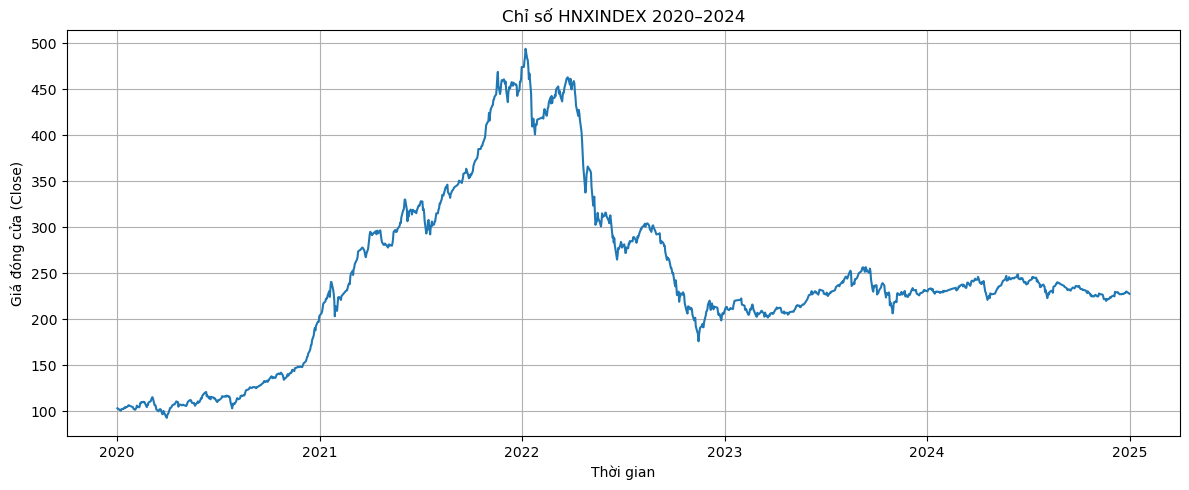

In [17]:
# biểu đồ thể hiện chỉ số Close của HNXINDEX (CSV)
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(data["Date"], data["Close"])
plt.title("Chỉ số HNXINDEX 2020–2024")
plt.xlabel("Thời gian")
plt.ylabel("Giá đóng cửa (Close)")
plt.grid(True)
plt.tight_layout()
plt.show()

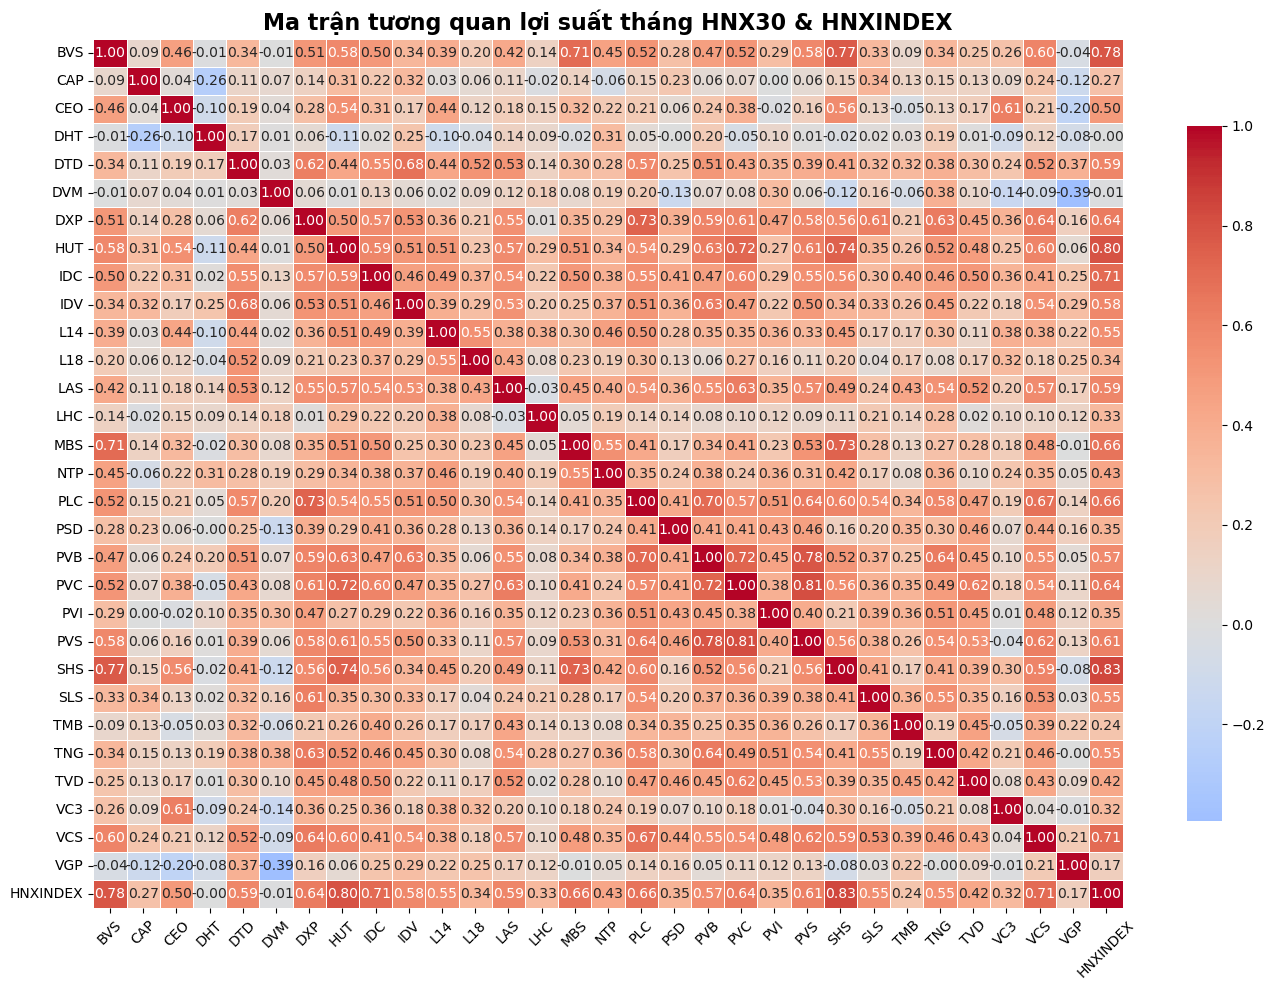

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 10))
sns.heatmap(
    monthly_returns_df.corr(),
    cmap="coolwarm",
    center=0,
    annot=True,          # Hiển thị số trong từng ô
    fmt=".2f",           # Làm tròn 2 số thập phân
    linewidths=0.5,      # Đường ngăn giữa các ô
    linecolor="white",   # Màu trắng giúp dễ nhìn
    cbar_kws={"shrink": 0.8}  # Thu nhỏ thanh màu
)
plt.title("Ma trận tương quan lợi suất tháng HNX30 & HNXINDEX", fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

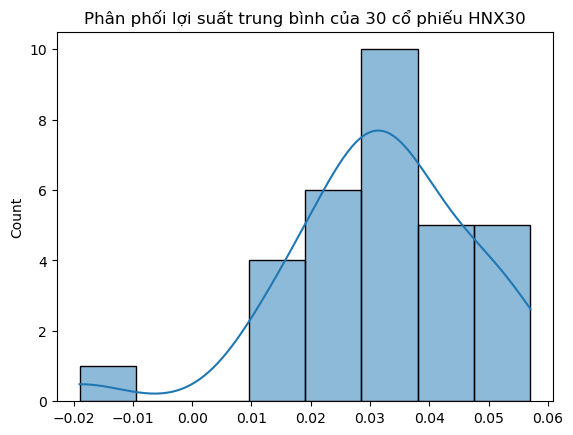

In [19]:
sns.histplot(monthly_returns_df.mean(), kde=True)
plt.title("Phân phối lợi suất trung bình của 30 cổ phiếu HNX30")
plt.show()

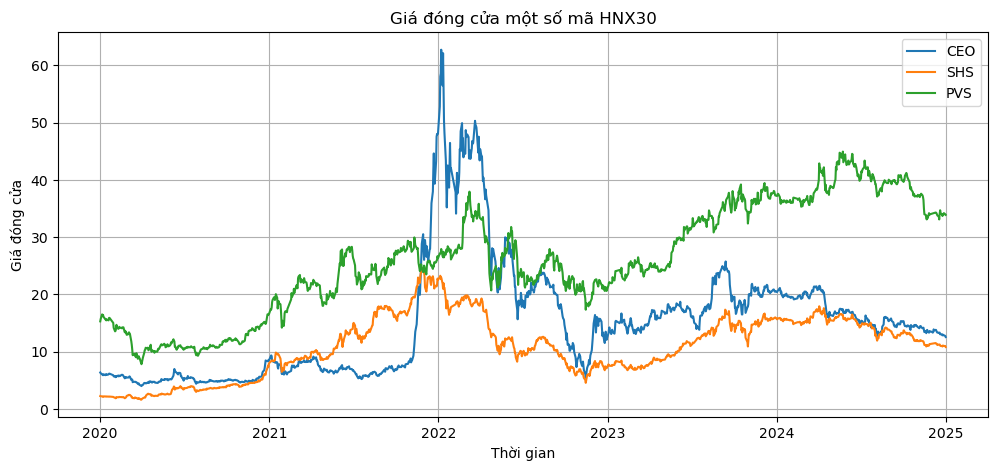

In [20]:
#Giá của một vài mã HNX30 ví dụ CEO, SHS, PVS
plt.figure(figsize=(12,5))
for ticker in ["CEO", "SHS", "PVS"]:
    df = hnx30_data[ticker]
    plt.plot(df["Date"], df["Close"], label=ticker)
plt.title("Giá đóng cửa một số mã HNX30")
plt.xlabel("Thời gian")
plt.ylabel("Giá đóng cửa")
plt.legend()
plt.grid(True)
plt.show()

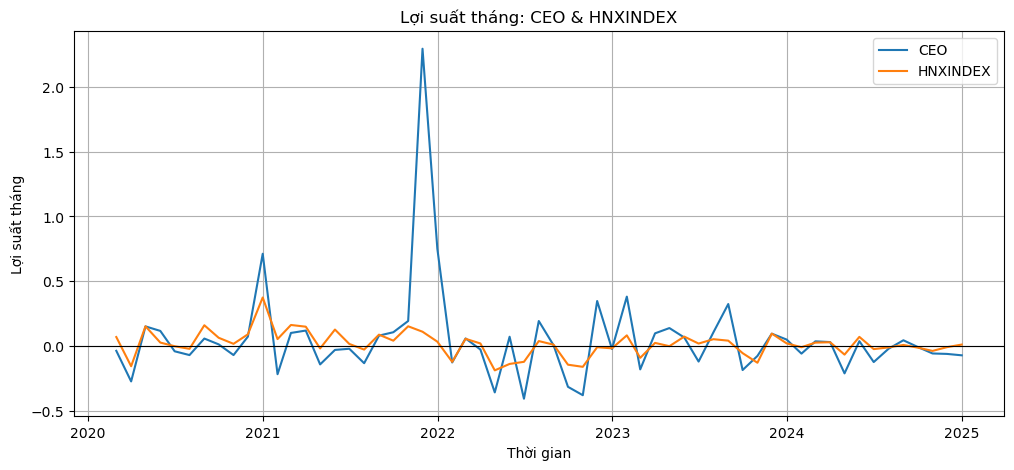

In [21]:
#Lợi suất tháng HNXINDEX vs 1 mã tự chọn là CEO
plt.figure(figsize=(12,5))
plt.plot(monthly_returns_df.index, monthly_returns_df["CEO"], label="CEO")
plt.plot(monthly_returns_df.index, monthly_returns_df["HNXINDEX"], label="HNXINDEX")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Lợi suất tháng: CEO & HNXINDEX")
plt.xlabel("Thời gian")
plt.ylabel("Lợi suất tháng")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# Loại HNXINDEX ra, chỉ giữ cổ phiếu, tính độ lệch chuẩn lợi suất tháng cho từng mã
stock_cols = [c for c in monthly_returns_df.columns if c != "HNXINDEX"]
vol_stats = monthly_returns_df[stock_cols].std().sort_values(ascending=False)
vol_stats.head(10)  # TOP 10 mã biến động mạnh nhất

CEO    0.363312
L14    0.248486
L18    0.242487
MBS    0.214685
VGP    0.199728
SHS    0.197881
DTD    0.195342
PVB    0.194186
TVD    0.192029
HUT    0.182796
dtype: float64

In [23]:
avg_volume = {
    t: df["Volume"].mean()
    for t, df in hnx30_data.items()
}
avg_volume = pd.Series(avg_volume).sort_values(ascending=False)
avg_volume.head(10)  # TOP 10 mã thanh khoản cao

SHS    1.109147e+07
PVS    7.189315e+06
CEO    5.979417e+06
HUT    3.778807e+06
IDC    2.401136e+06
MBS    2.266487e+06
TNG    2.203199e+06
PVC    1.277304e+06
LAS    7.822369e+05
DVM    5.154547e+05
dtype: float64

=== ADF Test CEO Monthly Return ===
ADF Statistic: -6.129225036925019
p-value: 8.481358054699576e-08
=> Chuỗi dừng

=== Mô hình ARIMA tốt nhất ===
Order (p,0,q): (0, 0, 1)
AIC: 50.45032808895671
                               SARIMAX Results                                
Dep. Variable:                    CEO   No. Observations:                   59
Model:                 ARIMA(0, 0, 1)   Log Likelihood                 -22.225
Date:                Fri, 21 Nov 2025   AIC                             50.450
Time:                        21:08:35   BIC                             56.683
Sample:                    02-29-2020   HQIC                            52.883
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          

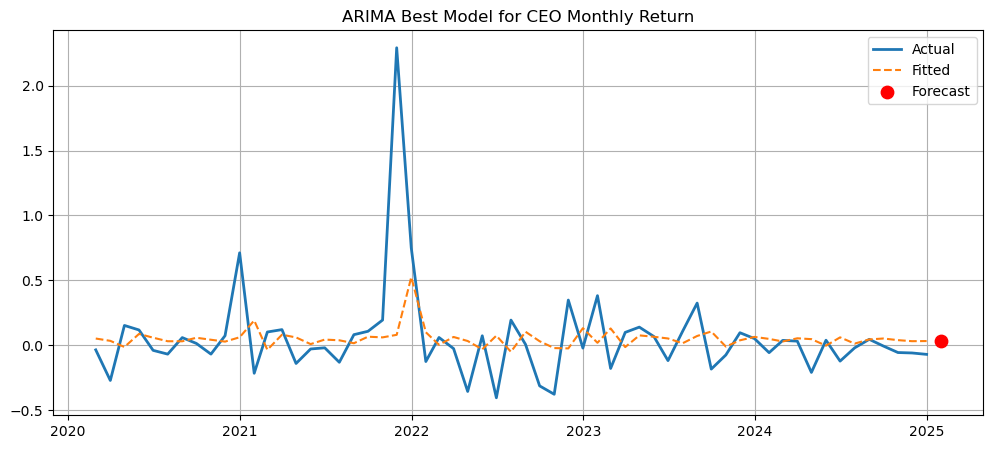

In [24]:
# 1. Lấy chuỗi lợi suất CEO
ri = monthly_returns_df["CEO"].dropna()
# 2. Kiểm định tính dừng ADF
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(ri)

print("=== ADF Test CEO Monthly Return ===")
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("=> Chuỗi dừng" if adf_result[1] < 0.05 else "=> Chuỗi KHÔNG dừng")

# 3. Grid Search ARIMA (p,0,q)
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.arima.model import ARIMA

best_aic = 1e9
best_order = None
best_model = None

for p in range(4):
    for q in range(4):
        try:
            model = ARIMA(ri, order=(p,0,q)).fit()
            if model.aic < best_aic:
                best_aic = model.aic
                best_order = (p,0,q)
                best_model = model
        except:
            continue

print("\n=== Mô hình ARIMA tốt nhất ===")
print("Order (p,0,q):", best_order)
print("AIC:", best_aic)

# 4. Kết quả mô hình

print(best_model.summary())

# 5. Dự báo tháng kế tiếp

forecast = best_model.forecast(steps=1)[0]
print("\nDự báo lợi suất tháng kế tiếp của CEO:", forecast)

# 6. Vẽ biểu đồ Actual vs Fitted vs Forecast

import matplotlib.pyplot as plt
import pandas as pd
plt.figure(figsize=(12,5))
plt.plot(ri.index, ri, label="Actual", linewidth=2)
fitted_vals = best_model.fittedvalues
plt.plot(fitted_vals.index, fitted_vals, label="Fitted", linestyle="--")
# Forecast point
next_date = ri.index[-1] + pd.DateOffset(months=1)
plt.scatter(next_date, forecast, color='red', label='Forecast', s=80, zorder=5)
plt.title("ARIMA Best Model for CEO Monthly Return")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
#Tính beta cho 30 cổ phiếu 
import pandas as pd
import statsmodels.api as sm
def calculate_beta(monthly_returns_df, market_col="HNXINDEX", min_data_points=10):
    stock_cols = [c for c in monthly_returns_df.columns if c != market_col]
    rm = monthly_returns_df[market_col]
    rows = []
    for ticker in stock_cols:
        ri = monthly_returns_df[ticker]
        df_tmp = pd.concat([ri, rm], axis=1).dropna()
        df_tmp.columns = ["ri", "rm"]

        # Kiểm tra số lượng dữ liệu đủ không
        if len(df_tmp) < min_data_points:
            print(f"Chú ý: Mã {ticker} có dữ liệu ít ({len(df_tmp)} tháng), vẫn sẽ tính beta với cảnh báo.")
        
        try:
            X = sm.add_constant(df_tmp["rm"])
            y = df_tmp["ri"]
            model = sm.OLS(y, X).fit()
            alpha = model.params["const"]
            beta = model.params["rm"]
            r2 = model.rsquared
            p_beta = model.pvalues["rm"]
            rows.append([ticker, alpha, beta, r2, p_beta])
        except Exception as e:
            print(f"Lỗi khi tính beta cho {ticker}: {e}")
            # Thêm hàng với NaN nếu lỗi
            rows.append([ticker, float('nan'), float('nan'), float('nan'), float('nan')])
    
    beta_table = (
        pd.DataFrame(rows, columns=["Ticker", "Alpha", "Beta", "R2", "Pvalue_Beta"])
        .set_index("Ticker")
        .sort_values("Beta")
    )
    return beta_table
# Ví dụ sử dụng:
# monthly_returns_df là dataframe đã chuẩn bị với dữ liệu từ 01/01/2020 (~5 năm),
# bao gồm cột "HNXINDEX" và các mã cổ phiếu trong danh mục HNX30 hoặc VN30.
beta_table = calculate_beta(monthly_returns_df, market_col="HNXINDEX", min_data_points=10)
print(beta_table)
# Bạn có thể kiểm tra beta_table.shape để xác nhận đủ 30 mã.

           Alpha      Beta        R2   Pvalue_Beta
Ticker                                            
DVM    -0.019072 -0.014903  0.000099  9.590651e-01
DHT     0.036552 -0.002759  0.000004  9.877512e-01
CAP     0.029624  0.227166  0.071266  4.096158e-02
PVI     0.015227  0.289538  0.122275  6.632756e-03
VGP     0.030097  0.357943  0.029644  2.318429e-01
TMB     0.044971  0.376043  0.059716  6.450462e-02
LHC     0.028714  0.383508  0.106092  1.182203e-02
VC3     0.017346  0.396366  0.100066  1.465313e-02
NTP     0.020352  0.486686  0.187440  6.151048e-04
PSD     0.010469  0.515898  0.124833  6.051977e-03
IDV     0.004730  0.539591  0.332494  1.755698e-06
VCS    -0.003150  0.758786  0.499742  3.914383e-10
SLS     0.027409  0.780771  0.304614  5.863935e-06
TVD     0.015083  0.850555  0.180507  7.964259e-04
L18     0.041463  0.864750  0.117011  8.006860e-03
PVS     0.008688  0.924135  0.376036  2.426848e-07
IDC     0.015569  0.937870  0.503334  3.177032e-10
TNG     0.015104  0.945541  0.2

In [26]:
# Sắp xếp Beta
beta_sorted = beta_table.sort_values("Beta")
# Top 10 Beta thấp → ổn định
danh_muc_on_dinh = beta_sorted.head(10)
# Top 10 Beta cao → mạo hiểm
danh_muc_mao_hiem = beta_sorted.tail(10)
print("Danh mục ổn định:\n", danh_muc_on_dinh)
print("\nDanh mục mạo hiểm:\n", danh_muc_mao_hiem)

Danh mục ổn định:
            Alpha      Beta        R2  Pvalue_Beta
Ticker                                           
DVM    -0.019072 -0.014903  0.000099     0.959065
DHT     0.036552 -0.002759  0.000004     0.987751
CAP     0.029624  0.227166  0.071266     0.040962
PVI     0.015227  0.289538  0.122275     0.006633
VGP     0.030097  0.357943  0.029644     0.231843
TMB     0.044971  0.376043  0.059716     0.064505
LHC     0.028714  0.383508  0.106092     0.011822
VC3     0.017346  0.396366  0.100066     0.014653
NTP     0.020352  0.486686  0.187440     0.000615
PSD     0.010469  0.515898  0.124833     0.006052

Danh mục mạo hiểm:
            Alpha      Beta        R2   Pvalue_Beta
Ticker                                            
PLC     0.008469  1.069595  0.442149  9.251958e-09
PVB     0.008008  1.144587  0.319660  3.075795e-06
PVC     0.008426  1.180449  0.406558  5.605945e-08
DTD     0.025282  1.199709  0.347043  9.187443e-07
BVS     0.014496  1.321458  0.610297  2.888321e-13
L14

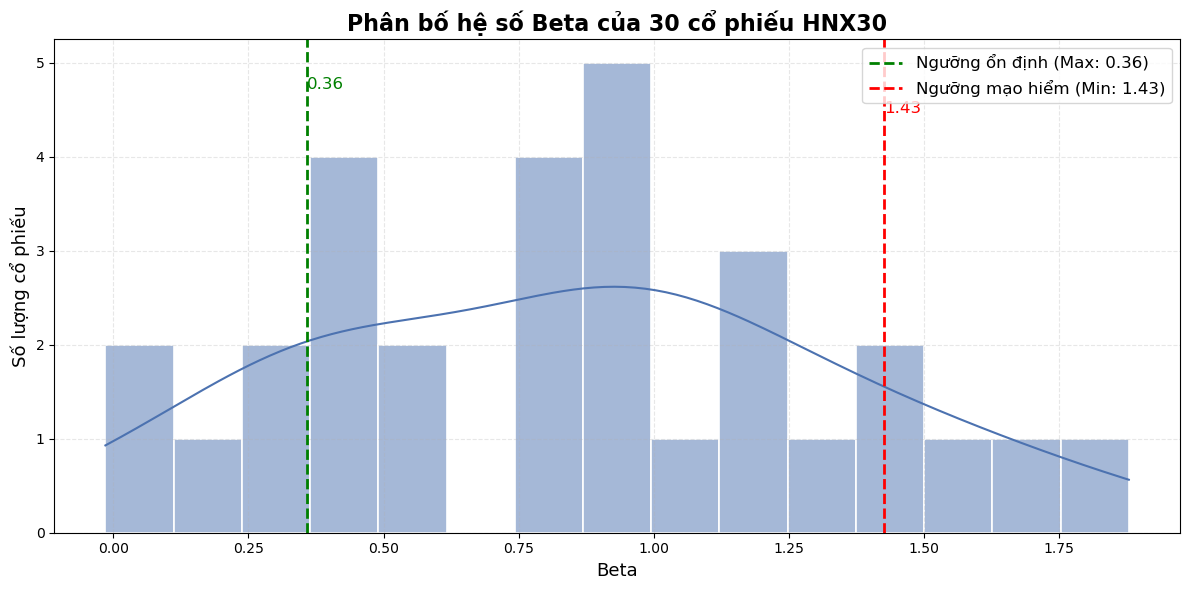

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
# Histogram + KDE
sns.histplot(
    beta_table['Beta'],
    bins=15,
    kde=True,
    color="#4C72B0",      # xanh dương dịu mắt
    edgecolor="white",    # đường viền cột trắng
    linewidth=1.2
)
plt.title("Phân bố hệ số Beta của 30 cổ phiếu HNX30",
          fontsize=16, fontweight='bold')
plt.xlabel("Beta", fontsize=13)
plt.ylabel("Số lượng cổ phiếu", fontsize=13)
# --- Vẽ các ngưỡng Beta ---
beta_on_dinh = danh_muc_on_dinh['Beta'].max()
beta_mao_hiem = danh_muc_mao_hiem['Beta'].min()
plt.axvline(beta_on_dinh, color='green', linestyle='--', linewidth=2,
            label=f'Ngưỡng ổn định (Max: {beta_on_dinh:.2f})')
plt.axvline(beta_mao_hiem, color='red', linestyle='--', linewidth=2,
            label=f'Ngưỡng mạo hiểm (Min: {beta_mao_hiem:.2f})')
# Thêm chú thích trực tiếp trên biểu đồ
plt.text(beta_on_dinh, plt.ylim()[1]*0.9,
         f"{beta_on_dinh:.2f}", color="green", fontsize=12)
plt.text(beta_mao_hiem, plt.ylim()[1]*0.85,
         f"{beta_mao_hiem:.2f}", color="red", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
n = 5
beta_sorted = beta_table.sort_values("Beta")
# Lấy 5 mã beta thấp nhất: danh mục ổn định
danh_muc_on_dinh = beta_sorted.head(5)
# Lấy 5 mã beta cao nhất: danh mục mạo hiểm
danh_muc_mao_hiem = beta_sorted.tail(5)
print("Danh mục ổn định (5 mã):")
print(danh_muc_on_dinh[['Beta']])
print("\nDanh mục mạo hiểm (5 mã):")
print(danh_muc_mao_hiem[['Beta']])

Danh mục ổn định (5 mã):
            Beta
Ticker          
DVM    -0.014903
DHT    -0.002759
CAP     0.227166
PVI     0.289538
VGP     0.357943

Danh mục mạo hiểm (5 mã):
            Beta
Ticker          
L14     1.427318
MBS     1.485483
HUT     1.519171
SHS     1.718282
CEO     1.879937


In [29]:
# ------------------ TÍNH LỢI SUẤT DANH MỤC ------------------
low_tickers = danh_muc_on_dinh.index.tolist()
high_tickers = danh_muc_mao_hiem.index.tolist()
# Equal-weight portfolio return
low_port_ret = monthly_returns_df[low_tickers].mean(axis=1)
high_port_ret = monthly_returns_df[high_tickers].mean(axis=1)
market_ret = monthly_returns_df["HNXINDEX"]
# Gộp thành DataFrame
port_df = pd.DataFrame({
    "LowBeta": low_port_ret,
    "HighBeta": high_port_ret,
    "Market": market_ret
}).dropna()
import numpy as np
def perf_stats(r):
    cum = (1 + r).cumprod()
    total_return = cum.iloc[-1] - 1
    mean_ret = r.mean()
    vol = r.std()
    sharpe = mean_ret / vol if vol != 0 else np.nan
    roll_max = cum.cummax()
    dd = cum / roll_max - 1
    max_dd = dd.min()
    return pd.Series({
        "Lợi suất TB": mean_ret,
        "Độ biến động": vol,
        "Tỷ lệ Sharpe": sharpe,
        "Tổng lợi nhuận": total_return,
        "Sụt giảm tối đa": max_dd
    })
# Tính hiệu quả danh mục
stats = port_df.apply(perf_stats)
print(stats)

                  LowBeta  HighBeta    Market
Lợi suất TB      0.026395  0.046333  0.018008
Độ biến động     0.059523  0.187089  0.095921
Tỷ lệ Sharpe     0.443438  0.247652  0.187742
Tổng lợi nhuận   3.227652  4.873737  1.221864
Sụt giảm tối đa -0.134285 -0.699042 -0.573029


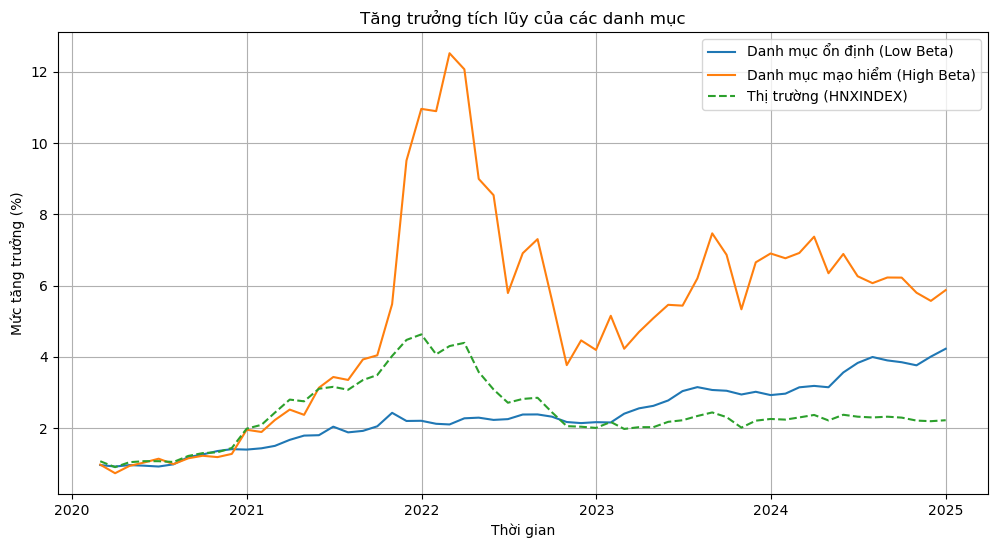

In [30]:
import matplotlib.pyplot as plt
cum_df = (1 + port_df).cumprod()
plt.figure(figsize=(12,6))
plt.plot(cum_df.index, cum_df["LowBeta"], label="Danh mục ổn định (Low Beta)")
plt.plot(cum_df.index, cum_df["HighBeta"], label="Danh mục mạo hiểm (High Beta)")
plt.plot(cum_df.index, cum_df["Market"], label="Thị trường (HNXINDEX)", linestyle="--")
plt.title("Tăng trưởng tích lũy của các danh mục")
plt.xlabel("Thời gian")
plt.ylabel("Mức tăng trưởng (%)")
plt.legend()
plt.grid(True)
plt.show()